## Imports and setup

Use install cell below to install whatever libraries you do not have

In [1]:
!pip install -qU imblearn

In [2]:
%config InlineBackend.figure_formats = ['svg']
%matplotlib inline

# basic algebra and system libraries
import matplotlib.pyplot as plt
import numpy as np
import os
import os.path as path
import pandas as pd
import gc
from tqdm.notebook import tqdm
import datetime
import seaborn as sns

# signal discrete fourier transform and loading
import scipy.signal as signal
import scipy.io.wavfile as wavfile
import scipy.fft as fft

# audio preprocessing, cross-validation, and others
from sklearn.base import TransformerMixin, BaseEstimator, ClassifierMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, precision_score, recall_score
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from imblearn.over_sampling import RandomOverSampler
from mpl_toolkits.mplot3d import Axes3D

# construction of convolutional neural network
import keras
import keras.optimizers as optimizers
import keras.layers as layers
import keras.losses as losses
import keras.metrics as metrics
import keras.regularizers as regularizers
from keras.callbacks import Callback
from tensorflow.keras import Input, Model
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ModelCheckpoint
import tensorflow as tf

# math
from math import ceil, sqrt

# audio analysis
import librosa
import librosa.display

# graph 
from itertools import cycle

tf.config.set_visible_devices([], 'GPU') # turn off GPUs

2025-01-27 23:00:59.022428: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-27 23:00:59.198496: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1738015259.267745   10967 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1738015259.291389   10967 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-27 23:00:59.435968: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [3]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


## Data pre-processing

The following cell sets up the core functions and constants for processing raw audio data into a format suitable for training a Convolutional Neural Network (CNN). It:
1. Defines key constants for data paths and audio processing.
2. Loads metadata for audio files and associates labels based on the speaker.
3. Provides functionality to split audio into fixed-length segments.
4. Generates Mel spectrograms from the audio segments.
5. Processes metadata, linking audio paths to their segments and corresponding spectrograms.

#### Key Elements:
1. **Constants**:
   - `DATA_DIR`: Path to raw audio files.
   - `CLASS_1_SPEAKERS`: List of speakers labeled as class 1.
   - `TARGET_SR` and `SEGMENT_LENGTH`: Sampling rate and audio segment length.

2. **Functions**:
   - `load_metadata`: Loads metadata, creating a DataFrame with file paths and labels.
   - `load_and_split_audio`: Splits audio files into fixed-length segments.
   - `generate_spectrogram`: Converts audio segments into Mel spectrograms.
   - `process_metadata`: Iterates through metadata, generates spectrograms, and associates them with labels.

In [4]:
# Define constants
DATA_DIR = os.path.join(".." ,"data", "raw")
CLASS_1_SPEAKERS = ['f1', 'f7', 'f8', 'm3', 'm6', 'm8']
TARGET_SR = 16000
SEGMENT_LENGTH = 1

def load_metadata(data_dir, class_1_speakers):
    """
    Loads metadata for audio files and assigns labels based on speaker identity.

    Args:
        data_dir (str): Path to the directory containing raw audio files.
        class_1_speakers (list): List of speaker IDs for class 1.

    Returns:
        pd.DataFrame: DataFrame containing file paths and corresponding labels.
    """
    metadata = []
    for root, _, files in os.walk(data_dir):
        for file in files:
            if file.endswith(".wav"):
                speaker_id = file.split('_')[0]
                label = 1 if speaker_id in class_1_speakers else 0
                metadata.append({'path': os.path.join(root, file), 'label': label})
    return pd.DataFrame(metadata)

def load_and_split_audio(file_path, target_sr=16000, segment_length=1):
    """
    Loads an audio file and splits it into fixed-length segments.

    Args:
        file_path (str): Path to the audio file.
        target_sr (int): Target sampling rate in Hz.
        segment_length (float): Length of each segment in seconds.

    Returns:
        list: List of audio segments (numpy arrays).
    """
    audio, sr = librosa.load(file_path, sr=target_sr)
    total_length = len(audio) / sr
    segments = []
    for start in np.arange(0, total_length, segment_length):
        end = start + segment_length
        segment = audio[int(start * sr):int(end * sr)]
        if len(segment) < segment_length * sr:  # Pad if shorter
            segment = np.pad(segment, (0, int(segment_length * sr) - len(segment)), mode='constant')
        segments.append(segment)
    return segments

def generate_spectrogram(segment, sr=16000):
    """
    Generates a Mel spectrogram from an audio segment.

    Args:
        segment (np.ndarray): Audio segment.
        sr (int): Sampling rate in Hz.

    Returns:
        np.ndarray: Mel spectrogram in decibel units.
    """
    S = librosa.feature.melspectrogram(y=segment, sr=sr, n_fft=2048, hop_length=512, n_mels=128)
    return librosa.power_to_db(S, ref=np.max)

def process_metadata(metadata, description):
    """
    Processes metadata to generate spectrograms and associate them with labels.

    Args:
        metadata (pd.DataFrame): DataFrame containing file paths and labels.
        description (str): Description for progress bar.

    Returns:
        tuple: Numpy arrays of spectrograms and labels.
    """
    spectrograms = []
    labels = []
    for _, row in tqdm(metadata.iterrows(), total=len(metadata), desc=description):
        segments = load_and_split_audio(row['path'], target_sr=TARGET_SR, segment_length=SEGMENT_LENGTH)
        for segment in segments:
            spectrogram = generate_spectrogram(segment, sr=TARGET_SR)
            spectrograms.append(spectrogram)
            labels.append(row['label'])
    return np.array(spectrograms), np.array(labels)

Following cell performs two critical steps:
1. **Splitting Metadata**: Divides the metadata into training and testing subsets while maintaining the class distribution (stratified split).
2. **Generating Spectrograms**: Processes the training and testing metadata to produce spectrograms and corresponding labels for model training and evaluation.

#### Key Elements:
1. **`train_test_split`**:
   - Splits `metadata_df` into `train_metadata` and `test_metadata`.
   - Ensures the class distribution remains balanced by stratifying on `label`.

2. **`process_metadata`**:
   - Converts audio file paths into spectrograms and labels for both training and testing subsets.

3. **Output**:
   - `X_train` and `Y_train`: Numpy arrays of spectrograms and labels for the training set.
   - `X_test` and `Y_test`: Numpy arrays of spectrograms and labels for the testing set.

In [5]:
# Load metadata
metadata_df = load_metadata(DATA_DIR, CLASS_1_SPEAKERS)

# Split metadata into training and testing sets
train_metadata, test_metadata = train_test_split(
    metadata_df,
    test_size=0.2,                  # 20% of data for testing
    stratify=metadata_df['label'],  # Maintain class balance in the split
    random_state=42                 # Ensure reproducibility
)

print(f"Train set length: {len(train_metadata)}\nTest set length: {len(test_metadata)}")

# Generate spectrograms and labels for training and testing sets
X_train, Y_train = process_metadata(train_metadata, description="Processing Train Data")
X_test, Y_test = process_metadata(test_metadata, description="Processing Test Data")

Train set length: 80
Test set length: 21


Processing Train Data:   0%|          | 0/80 [00:00<?, ?it/s]

Processing Test Data:   0%|          | 0/21 [00:00<?, ?it/s]

Following two cells addresses the class imbalance in the training data by oversampling the minority class using `RandomOverSampler`. The second cell also reshapes the training and testing data to include a channel dimension required by CNNs, prints dataset statistics, and visualizes the balanced class distribution.

#### Functions:
1. `oversample_minority_class`: Balances the class distribution in the training data using `RandomOverSampler`.
2. `plot_class_distribution`: Plots the distribution of classes in the dataset.

#### Key Elements:
1. **Oversampling**:
   - Uses `RandomOverSampler` to generate additional samples for the minority class in the training data.
   - Reshapes `X_train` for compatibility with the oversampler and restores its original shape afterward.

2. **Channel Dimension**:
   - Adds a channel dimension (`[..., np.newaxis]`) to the training and testing data for compatibility with CNN input requirements.

3. **Visualization**:
   - Displays the class distribution in the training set after oversampling.

4. **Output**:
   - Prints the shapes of the training and testing datasets and the class distribution after oversampling.

In [6]:
def oversample_minority_class(X, Y, random_state=42):
    """
    Balances the class distribution in the training data using RandomOverSampler.

    Args:
        X (np.ndarray): Feature matrix of shape (n_samples, height, width).
        Y (np.ndarray): Labels array of shape (n_samples,).
        random_state (int): Seed for reproducibility.

    Returns:
        tuple: Resampled feature matrix and labels with balanced classes.
    """
    ros = RandomOverSampler(random_state=random_state)
    X_flat = X.reshape((X.shape[0], -1))  # Flatten for oversampling
    X_resampled_flat, Y_resampled = ros.fit_resample(X_flat, Y)
    X_resampled = X_resampled_flat.reshape((-1, X.shape[1], X.shape[2]))  # Restore original shape
    return X_resampled, Y_resampled

def plot_class_distribution(labels, title="Class Distribution", class_names=None):
    """
    Plots the distribution of classes in the dataset.

    Args:
        labels (np.ndarray): Array of labels.
        title (str): Plot title.
        class_names (list): Names of the classes (default is None).
    """
    counts = np.bincount(labels)
    plt.figure(figsize=(10, 5))
    plt.bar(class_names if class_names else range(len(counts)), counts)
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Number of Samples")
    plt.tight_layout()
    plt.show()

Training data shape (after oversampling): (17788, 128, 32, 1)
Test data shape: (3272, 128, 32, 1)
Class distribution in training data (after oversampling): [8894 8894]


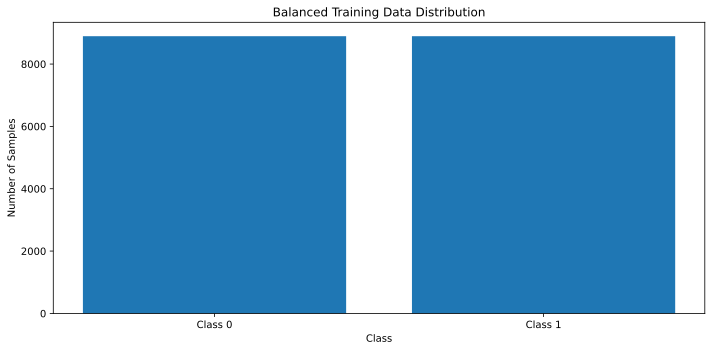

In [7]:
X_train_resampled, Y_train_resampled = oversample_minority_class(X_train, Y_train)

X_train_resampled = X_train_resampled[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print(f"Training data shape (after oversampling): {X_train_resampled.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Class distribution in training data (after oversampling): {np.bincount(Y_train_resampled)}")

plot_class_distribution(
    Y_train_resampled,
    title="Balanced Training Data Distribution",
    class_names=['Class 0', 'Class 1']
)

Following cells visualize the spectrogram data by:
1. **Plotting Example Spectrograms**:
   - Displays a few spectrograms from the training and testing datasets, along with their class labels, for manual inspection.
   
2. **Plotting Histograms of Spectrogram Values**:
   - Analyzes the distribution of spectrogram values for each class in both the training and testing datasets.

#### Key Elements:
1. **`plot_example_spectrograms`**:
   - Plots `num_examples` spectrograms with colorbars and labels for easy visualization.

2. **`plot_spectrogram_value_histograms`**:
   - Calculates the distribution of spectrogram values for each class and displays overlaid histograms.

3. **Visualization Tools**:
   - Uses `librosa.display.specshow` for spectrogram rendering and `matplotlib` for plotting.

In [8]:
def plot_example_spectrograms(X, Y, num_examples=3, sr=16000, hop_length=512, title_prefix="Dataset"):
    """
    Plots example spectrograms with their corresponding labels.

    Args:
        X (np.ndarray): Spectrogram data of shape (n_samples, height, width, channels).
        Y (np.ndarray): Labels array of shape (n_samples,).
        num_examples (int): Number of spectrograms to display.
        sr (int): Sampling rate in Hz.
        hop_length (int): Hop length for the spectrogram.
        title_prefix (str): Prefix for the plot titles.
    """
    plt.figure(figsize=(10, 3))
    for i in range(num_examples):
        plt.subplot(1, num_examples, i + 1)
        spectrogram = X[i].squeeze()  # Remove channel dimension
        librosa.display.specshow(spectrogram, sr=sr, hop_length=hop_length, x_axis='time', y_axis='mel')
        plt.title(f"{title_prefix} - Label: {Y[i]}")
        plt.colorbar(format='%+2.0f dB')
    plt.tight_layout()
    plt.show()

def plot_spectrogram_value_histograms(X, Y, title_prefix="Dataset"):
    """
    Plots histograms of spectrogram values for each class in the dataset.

    Args:
        X (np.ndarray): Spectrogram data of shape (n_samples, height, width, channels).
        Y (np.ndarray): Labels array of shape (n_samples,).
        title_prefix (str): Prefix for the plot titles.
    """
    class_0_values = np.concatenate([X[i].squeeze().ravel() for i in range(len(Y)) if Y[i] == 0])
    class_1_values = np.concatenate([X[i].squeeze().ravel() for i in range(len(Y)) if Y[i] == 1])

    # Plot histogram
    plt.figure(figsize=(10, 5))
    plt.hist(class_0_values, bins=50, alpha=0.5, label='Class 0', color='blue')
    plt.hist(class_1_values, bins=50, alpha=0.5, label='Class 1', color='orange')
    plt.title(f"Histogram of Spectrogram Values ({title_prefix} Set)")
    plt.xlabel("Value (dB)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

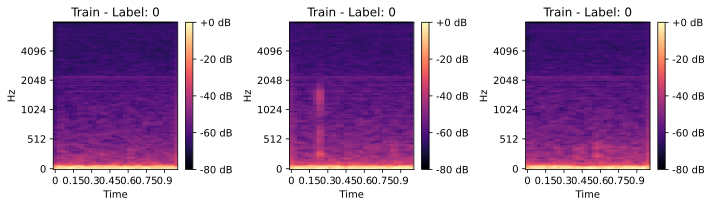

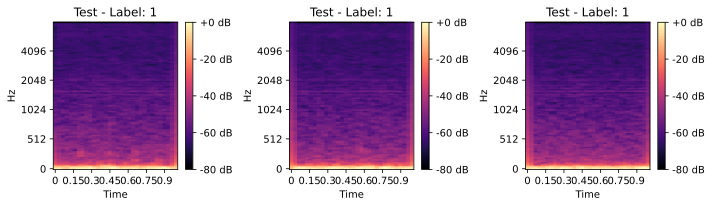

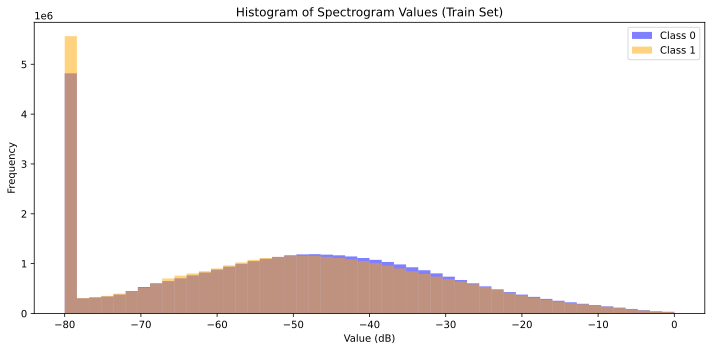

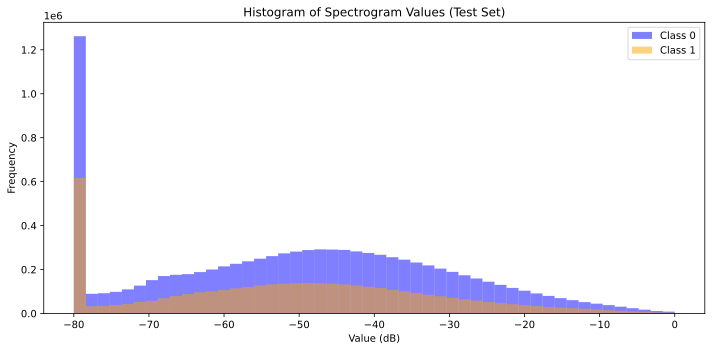

In [9]:
# Visualize example spectrograms from the training and testing sets
plot_example_spectrograms(X_train_resampled, Y_train_resampled, num_examples=3, title_prefix="Train")
plot_example_spectrograms(X_test, Y_test, num_examples=3, title_prefix="Test")

# Visualize histograms of spectrogram values for training and testing sets
plot_spectrogram_value_histograms(X_train_resampled, Y_train_resampled, title_prefix="Train")
plot_spectrogram_value_histograms(X_test, Y_test, title_prefix="Test")

## Parameter Space and Reinitialization Robustness

This cell provides tools to monitor, analyze, and visualize the changes in neural network layer weights during training, with additional functionality for layer reinitialization.


#### Key Elements
1. **Monitor Layer Changes Class**:
    - Captures weight changes for each trainable layer at specified intervals.
    - Tracks cumulative weight updates across epochs.

2. **Reinitialization Function**:
    - Resets weights of a specified layer using its kernel initializer.

3. **Plotting Functions**:
    - Visualizes weight changes, including:
      - Per-layer and aggregate weight changes.
      - Cumulative weight changes.
      - Recovery after layer reinitialization.
      - Heatmaps of weight changes across epochs.
    - Displays the distribution of parameters for a layer at a given epoch.

In [10]:
# Callback to monitor and log layer weight changes
class MonitorLayerChanges(Callback):
    def __init__(self, model, log_interval=1):
        super().__init__()
        self._model = model
        self.log_interval = log_interval
        self.initial_weights = {layer.name: layer.get_weights() for layer in model.layers}
        self.weight_changes = {layer.name: [] for layer in model.layers}

    def on_epoch_end(self, epoch, logs=None):
        if epoch % self.log_interval == 0:
            for layer in self._model.layers:
                if layer.trainable:
                    new_weights = layer.get_weights()
                    change = np.sum([
                        np.linalg.norm(new - old)
                        for new, old in zip(new_weights, self.initial_weights[layer.name])
                    ])
                    self.weight_changes[layer.name].append(change)
                    self.initial_weights[layer.name] = new_weights

def reinitialize_layer(model, layer_name):
    for layer in model.layers:
        if layer.name == layer_name:
            # Reinitialize kernel weights
            new_kernel = layer.kernel_initializer(
                shape=layer.get_weights()[0].shape
            )
            if layer.use_bias:
                new_bias = layer.bias_initializer(
                    shape=layer.get_weights()[1].shape
                )
                layer.set_weights([new_kernel, new_bias])
            else:
                layer.set_weights([new_kernel])


# Function to plot weight changes for individual layers and aggregate comparison
def plot_weight_changes(weight_changes, reinit_epoch, reinit_layer):
    # Set color palette and cycle
    color_palette = plt.cm.tab20.colors  
    color_cycle = cycle(color_palette)

    # Plot aggregate comparison of all layers
    plt.figure(figsize=(12, 8))
    for layer_name, changes in weight_changes.items():
        plt.plot(
            range(1, len(changes) + 1), 
            changes, 
            marker='o', 
            label=f'{layer_name}',
            color=next(color_cycle)
        )

    plt.title('Weight Changes Across Layers', fontsize=16)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Weight Change Magnitude', fontsize=12)
    plt.axvline(x=reinit_epoch, color='r', linestyle='--', label='Reinitialization Point')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    plt.grid()
    plt.tight_layout()
    plt.show()

    # Reset color cycle for cumulative plot
    color_cycle = cycle(color_palette)

    # Plot cumulative weight change for each layer
    plt.figure(figsize=(12, 8))
    for layer_name, changes in weight_changes.items():
        cumulative_changes = np.cumsum(changes)
        plt.plot(
            range(1, len(cumulative_changes) + 1), 
            cumulative_changes, 
            marker='o', 
            label=f'{layer_name}',
            color=next(color_cycle)
        )

    plt.title('Cumulative Weight Changes Across Layers', fontsize=16)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Cumulative Weight Change', fontsize=12)
    plt.axvline(x=reinit_epoch, color='r', linestyle='--', label='Reinitialization Point')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    plt.grid()
    plt.tight_layout()
    plt.show()

    # Plot comparison of post-reinitialization recovery
    if reinit_layer in weight_changes:
        changes = weight_changes[reinit_layer]
        post_reinit = changes[reinit_epoch - 1:]
        plt.figure(figsize=(8, 5))
        plt.plot(range(reinit_epoch, reinit_epoch + len(post_reinit)), post_reinit, marker='o', label='Post-Reinit Changes')
        plt.title(f'Post-Reinitialization Recovery for {reinit_layer}')
        plt.xlabel('Epoch')
        plt.ylabel('Weight Change Magnitude')
        plt.grid()
        plt.legend()
        plt.show()

    # Heatmap of weight changes
    layers = list(weight_changes.keys())
    data = np.array([changes for changes in weight_changes.values()])
    plt.figure(figsize=(12, 8))
    sns.heatmap(data, annot=True, cmap="YlGnBu", xticklabels=range(1, len(data[0]) + 1), yticklabels=layers)
    plt.title('Heatmap of Weight Changes Across Layers')
    plt.xlabel('Epoch')
    plt.ylabel('Layers')
    plt.show()


def plot_all_epochs_distributions(param_distributions, num_epochs):

    num_layers = len(param_distributions)
    grid_size = ceil(sqrt(num_layers))

    fig = plt.figure(figsize=(15, 15))
    axes = []

    for i, (layer_name, all_weights) in enumerate(param_distributions.items()):
        ax = fig.add_subplot(grid_size, grid_size, i + 1, projection='3d')
        axes.append(ax)

        for epoch_idx, weights in enumerate(all_weights):
            hist, bins = np.histogram(weights, bins=30, density=True)
            bin_centers = 0.5 * (bins[:-1] + bins[1:])
            ax.bar(bin_centers, hist, zs=epoch_idx, zdir='y', alpha=0.7, width=(bins[1] - bins[0]))

        ax.set_title(f"{layer_name}")
        ax.set_xlabel("Weight Value")
        ax.set_ylabel("Epoch")
        ax.set_zlabel("Frequency")

    fig.suptitle("3D Parameter Distributions Across Layers and Epochs", fontsize=16)
    plt.tight_layout()
    plt.show()


## Training

This cell defines, compiles, and trains a Convolutional Neural Network (CNN) for binary classification. It incorporates callbacks for efficient training, including **Early Stopping** to prevent overfitting, **Model Checkpoints** to save the best model, and **TensorBoard** for tracking training progress.

#### Key Elements:
1. **CNN Architecture**:
   - A sequential CNN is built with:
     - Convolutional layers for feature extraction.
     - Batch normalization for faster convergence.
     - MaxPooling layers for dimensionality reduction.
     - Dense layers for classification, with a dropout for regularization.

2. **Callbacks**:
   - **TensorBoard**: Logs training metrics for visualization.
   - **Early Stopping**: Halts training if validation loss doesn't improve for 5 epochs.
   - **Model Checkpoints**: Saves the model with the best validation loss.

3. **Class Weights**:
   - Balances the loss function to address class imbalance using `compute_class_weight`.

4. **Training**:
   - Trains the CNN on the preprocessed spectrogram data using the specified callbacks.

In [11]:
def create_cnn(input_shape=(128, 32, 1)):
    """
    Creates and compiles a Convolutional Neural Network (CNN) for binary classification.

    Args:
        input_shape (tuple): Shape of the input data (height, width, channels).

    Returns:
        keras.Model: Compiled CNN model.
    """
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3, 3), activation='relu', name='conv1')(inputs)
    x = layers.BatchNormalization(name='batch_norm1')(x)
    x = layers.MaxPooling2D((2, 2), name='pool1')(x)

    x = layers.Conv2D(64, (3, 3), activation='relu', name='conv2')(x)
    x = layers.BatchNormalization(name='batch_norm2')(x)
    x = layers.MaxPooling2D((2, 2), name='pool2')(x)

    x = layers.Conv2D(128, (3, 3), activation='relu', name='conv3')(x)
    x = layers.BatchNormalization(name='batch_norm3')(x)
    x = layers.MaxPooling2D((2, 2), name='pool3')(x)

    x = layers.Flatten(name='flaten')(x)
    x = layers.Dense(128, activation='relu', name='dense1')(x)
    x = layers.Dropout(0.5, name='dropout')(x)
    outputs = layers.Dense(1, activation='sigmoid', name='output')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

Epoch 1/5


I0000 00:00:1738015424.020441   12186 service.cc:148] XLA service 0x71aed4011b70 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1738015424.020628   12186 service.cc:156]   StreamExecutor device (0): Host, Default Version
2025-01-27 23:03:44.111449: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1738015425.299895   12186 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


408/408 ━━━━━━━━━━━━━━━━━━━━ 0s 570ms/step - accuracy: 0.5967 - loss: 0.8658
Epoch 1: val_loss improved from inf to 0.49132, saving model to models/best_model.keras
408/408 ━━━━━━━━━━━━━━━━━━━━ 240s 580ms/step - accuracy: 0.5968 - loss: 0.8654 - val_accuracy: 0.7732 - val_loss: 0.4913
Epoch 2/5
408/408 ━━━━━━━━━━━━━━━━━━━━ 0s 554ms/step - accuracy: 0.7535 - loss: 0.4826
Epoch 1: val_loss improved from 0.49132 to 0.37243, saving model to models/best_model.keras
408/408 ━━━━━━━━━━━━━━━━━━━━ 229s 561ms/step - accuracy: 0.7535 - loss: 0.4825 - val_accuracy: 0.8200 - val_loss: 0.3724
Reinitialized layer conv1
Epoch 3/5
408/408 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy: 0.8325 - loss: 0.3574
Epoch 1: val_loss improved from 0.37243 to 0.30018, saving model to models/best_model.keras
408/408 ━━━━━━━━━━━━━━━━━━━━ 228s 560ms/step - accuracy: 0.8325 - loss: 0.3574 - val_accuracy: 0.8603 - val_loss: 0.3002
Epoch 4/5
408/408 ━━━━━━━━━━━━━━━━━━━━ 0s 553ms/step - accuracy: 0.8834 - loss: 0.2604
E

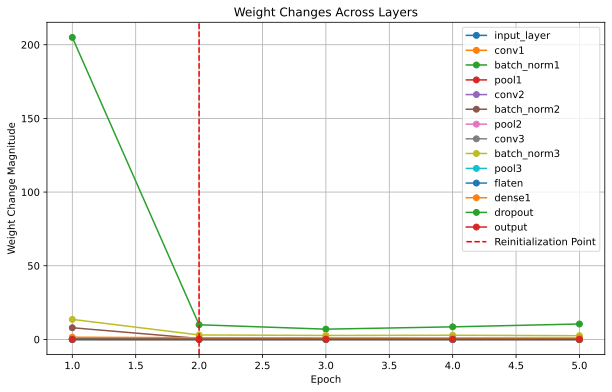

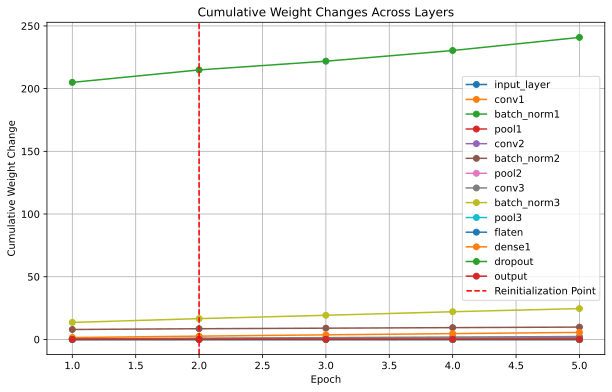

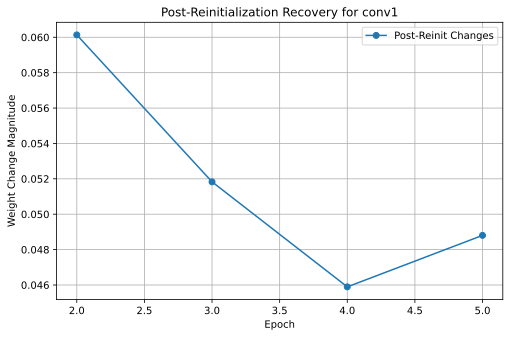

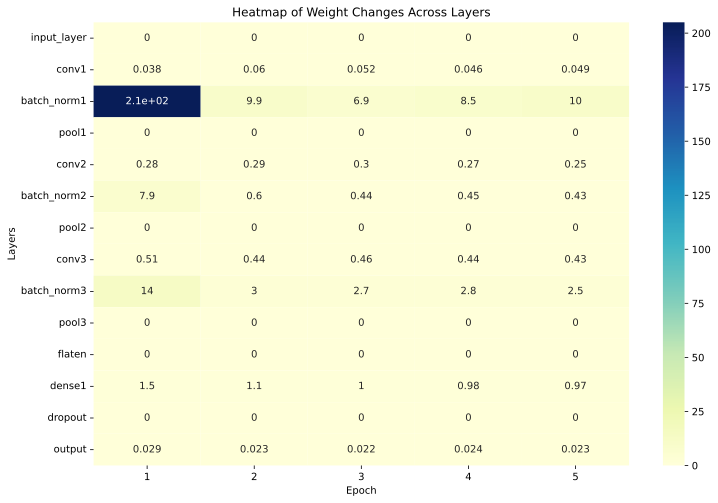

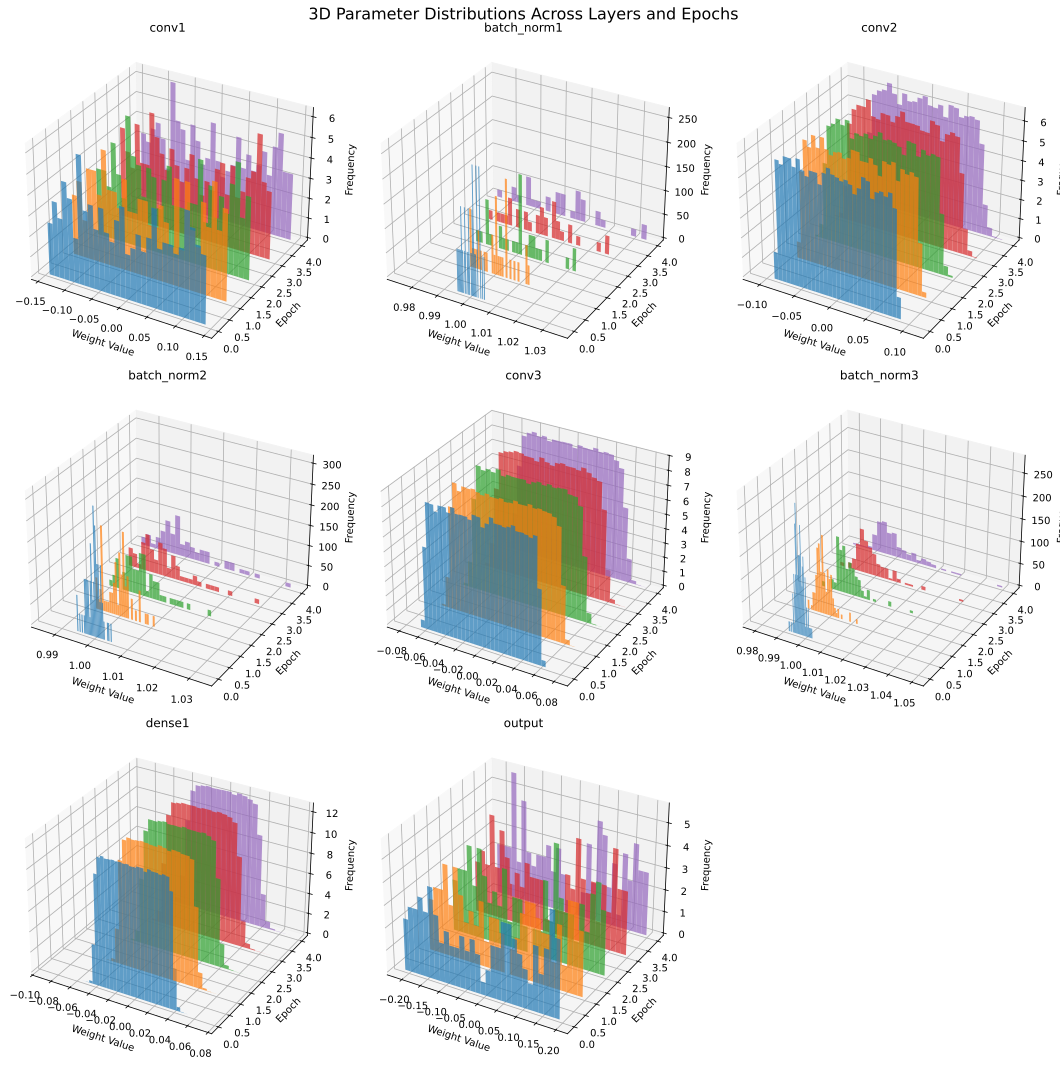

In [12]:
# Instantiate the CNN model
model = create_cnn()
monitor_callback = MonitorLayerChanges(model)

# Define TensorBoard callback for training visualization
log_dir = os.path.join("logs", "fit", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

# Define Early Stopping to prevent overfitting
early_stopping_callback = EarlyStopping(
    monitor='val_loss',       # Monitor validation loss
    patience=5,               # Stop if no improvement for 5 epochs
    restore_best_weights=True # Revert to the best weights
)

# Define Model Checkpoint to save the best model
checkpoint_path = path.join("models", "best_model.keras")
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',       # Save model with the best validation loss
    save_best_only=True,
    verbose=1
)

# Compute class weights to address class imbalance
class_weights = dict(enumerate(compute_class_weight('balanced', classes=np.unique(Y_train), y=Y_train)))

param_distributions = {layer.name: [] for layer in model.layers if layer.trainable and layer.get_weights()}

epochs = 5
reinit_epoch = 2
reinit_layers = ['conv1']

history = {
    'loss': [],
    'accuracy': [],
    'val_loss': [],
    'val_accuracy': []
}

# Train the CNN model
for epoch in range(epochs):
    print(f"Epoch {epoch + 1}/{epochs}")
    epoch_history = model.fit(
        X_train, Y_train,
        batch_size=32,                      # Batch size
        validation_data=(X_test, Y_test),   # Validation data
        callbacks=[
            tensorboard_callback,           # Logs training metrics
            early_stopping_callback,        # Stops training early if overfitting
            model_checkpoint_callback,      # Saves the best model
            monitor_callback,               # Monitors layer changes
        ],
        class_weight=class_weights,         # Adjusts loss for class imbalance

    )

    # Aggregate the metrics into the full history
    for key, values in epoch_history.history.items():
        history[key].extend(values)

    # Reinitialize specific layer at the specified epoch
    if epoch == reinit_epoch - 1:
        for reinit_layer in reinit_layers:
            reinitialize_layer(model, reinit_layer)
            print(f"Reinitialized layer {reinit_layer}")

    # Collect parameter distributions for this epoch
    for layer in model.layers:
        if layer.trainable and layer.get_weights():
            param_distributions[layer.name].append(layer.get_weights()[0].flatten())



# Plot weight changes for individual layers and aggregate comparison
plot_weight_changes(monitor_callback.weight_changes, reinit_epoch, reinit_layer)
plot_all_epochs_distributions(param_distributions, epochs)

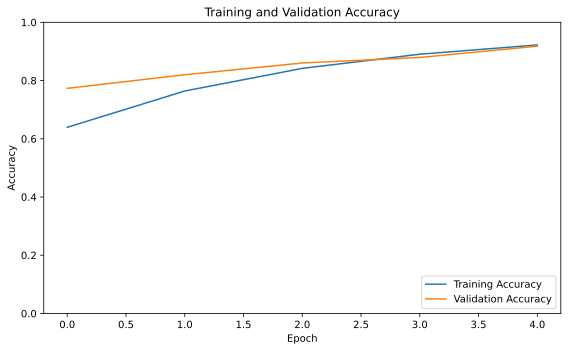

In [13]:
def plot_training_history(history):
    """
    Plots the training and validation accuracy over epochs.

    Args:
        history (keras.callbacks.History): Training history object returned by `model.fit`.
    """
    plt.figure(figsize=(8, 5))
    plt.plot(history['accuracy'], label='Training Accuracy')
    plt.plot(history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim([0, 1])
    plt.title('Training and Validation Accuracy')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

plot_training_history(history)

This cell evaluates the trained CNN model on the test set using standard classification metrics:
1. **Generate Predictions**: Predict class labels for the test set using the trained model.
2. **Evaluate Performance**: Calculate accuracy, precision, recall, and F1 score to assess model performance.
3. **Classification Report**: Provides detailed metrics for each class, including precision, recall, F1 score, and support.

#### Key Elements:
1. **`model.predict`**:
   - Predicts probabilities for the test set. Predictions are thresholded at `0.5` to determine binary class labels.

2. **Metrics**:
   - **Accuracy**: Fraction of correct predictions.
   - **Macro F1**: F1 score averaged across all classes, treating each class equally.
   - **Precision and Recall**: Key metrics for assessing the balance between false positives and false negatives.

3. **`classification_report`**:
   - Outputs a comprehensive report of precision, recall, and F1 score for each class.

In [14]:
def evaluate_model(model, X_test, Y_test, threshold=0.5):
    """
    Generates predictions, calculates evaluation metrics, and displays a classification report.

    Args:
        model (keras.Model): Trained CNN model.
        X_test (np.ndarray): Test feature data.
        Y_test (np.ndarray): True labels for the test data.
        threshold (float): Probability threshold for classifying predictions.

    Returns:
        dict: Dictionary containing calculated metrics (accuracy, F1, precision, recall).
    """
    Y_pred = (model.predict(X_test) > threshold).astype('int32')

    accuracy = accuracy_score(Y_test, Y_pred)
    macro_f1 = f1_score(Y_test, Y_pred, average='macro')
    precision = precision_score(Y_test, Y_pred, average='macro')
    recall = recall_score(Y_test, Y_pred, average='macro')

    print(f'Accuracy: {accuracy:.4f}')
    print(f'Macro F1: {macro_f1:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')

    print("\nClassification Report:")
    class_report = classification_report(Y_test, Y_pred)
    print(class_report)

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "precision": precision,
        "recall": recall
    }

metrics = evaluate_model(model, X_test, Y_test)

103/103 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step
Accuracy: 0.9181
Macro F1: 0.9035
Precision: 0.9056
Recall: 0.9015

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      2263
           1       0.87      0.86      0.87      1009

    accuracy                           0.92      3272
   macro avg       0.91      0.90      0.90      3272
weighted avg       0.92      0.92      0.92      3272



This cell visualizes the performance of the model using a confusion matrix, which highlights the number of correct and incorrect predictions for each class. It provides an intuitive way to assess where the model performs well and where it struggles.

#### Key Elements:
1. **`confusion_matrix`**:
   - Computes a 2x2 matrix for binary classification, showing:
     - True Positives (TP)
     - True Negatives (TN)
     - False Positives (FP)
     - False Negatives (FN)

2. **`sns.heatmap`**:
   - Displays the confusion matrix as a heatmap for better visualization.
   - Annotates cell values for clarity.

3. **Plot Customization**:
   - Includes axis labels and a title to improve interpretability.

103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step


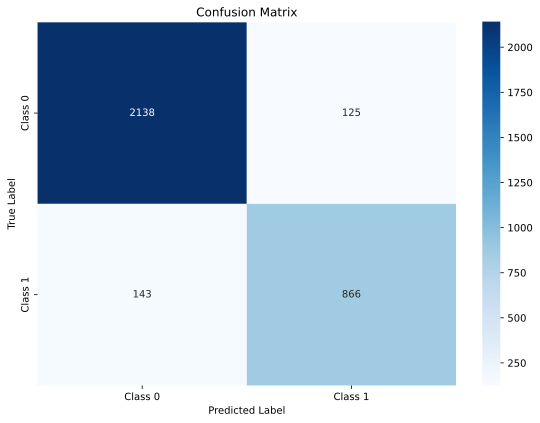

In [15]:
def plot_confusion_matrix(y_true, y_pred, class_names=None, title="Confusion Matrix"):
    """
    Plots a confusion matrix as a heatmap.

    Args:
        y_true (np.ndarray): True labels.
        y_pred (np.ndarray): Predicted labels.
        class_names (list): List of class names for the x and y axes (default: None).
        title (str): Title for the plot.
    """
    conf_matrix = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names if class_names else ['Class 0', 'Class 1'],
        yticklabels=class_names if class_names else ['Class 0', 'Class 1']
    )
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(title)
    plt.tight_layout()
    plt.show()

Y_pred = (model.predict(X_test) > 0.5).astype('int32')
plot_confusion_matrix(
    Y_test,
    Y_pred,
    class_names=['Class 0', 'Class 1'],
    title="Confusion Matrix"
)

This cell identifies and visualizes misclassified samples by:
1. **Locating Misclassified Indices**: Identifies indices where the true labels differ from the predicted labels.
2. **Visualizing Misclassified Spectrograms**: Displays a subset of misclassified spectrograms along with their true and predicted labels for error analysis.

#### Key Elements:
1. **Misclassification**:
   - `np.where(Y_test != Y_pred.flatten())[0]`: Extracts indices where predictions don't match true labels.

2. **Visualization**:
   - Plots spectrograms of misclassified samples in a grid layout for easy comparison.
   - Titles indicate the true and predicted labels for each spectrogram.

3. **Plot Layout**:
   - Uses a grid (2 rows x 5 columns for up to 10 samples) to display spectrograms.

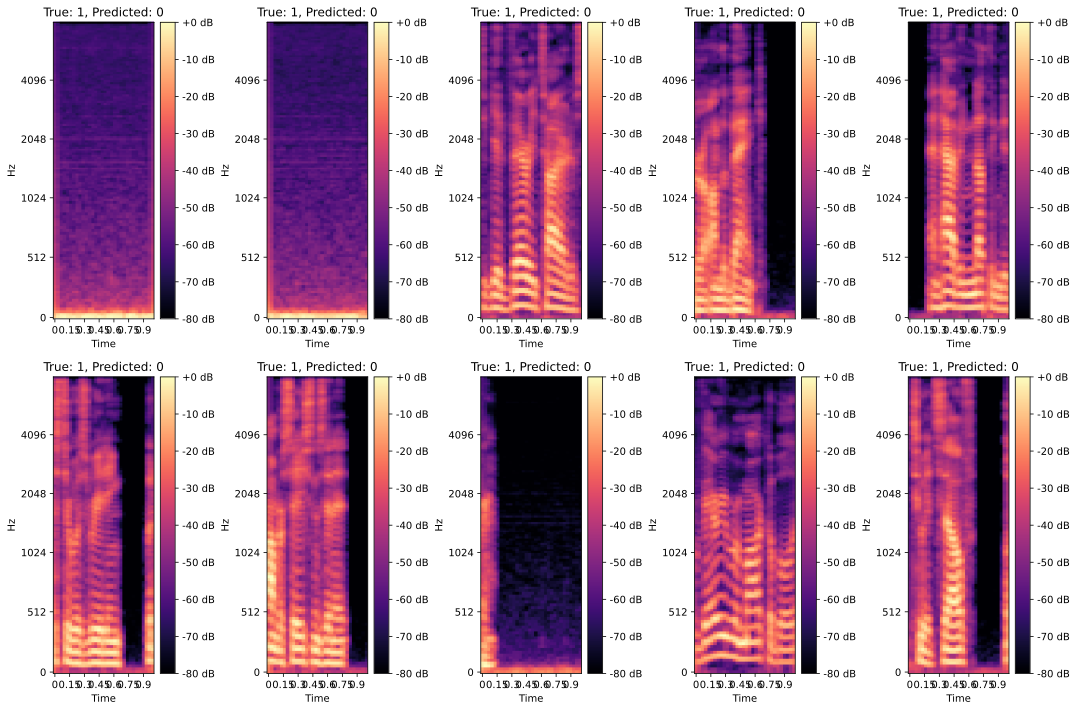

In [16]:
def plot_misclassified_spectrograms(X, Y_true, Y_pred, sr=16000, hop_length=512, num_to_plot=10):
    """
    Plots spectrograms of misclassified samples along with their true and predicted labels.

    Args:
        X (np.ndarray): Test feature data of shape (n_samples, height, width, channels).
        Y_true (np.ndarray): True labels.
        Y_pred (np.ndarray): Predicted labels.
        sr (int): Sampling rate in Hz.
        hop_length (int): Hop length for the spectrogram.
        num_to_plot (int): Number of misclassified samples to plot (default: 10).
    """
    # Find indices of misclassified samples
    misclassified_indices = np.where(Y_true != Y_pred.flatten())[0]

    # Limit the number of samples to plot
    num_to_plot = min(num_to_plot, len(misclassified_indices))
    if num_to_plot == 0:
        print("No misclassified samples to display.")
        return

    # Plot misclassified spectrograms
    plt.figure(figsize=(15, 10))
    for i in range(num_to_plot):
        idx = misclassified_indices[i]
        spectrogram = X[idx].squeeze()

        plt.subplot(2, 5, i + 1)
        librosa.display.specshow(
            spectrogram,
            sr=sr,
            hop_length=hop_length,
            x_axis='time',
            y_axis='mel'
        )
        plt.title(f"True: {Y_true[idx]}, Predicted: {Y_pred[idx][0]}")
        plt.colorbar(format="%+2.0f dB")

    plt.tight_layout()
    plt.show()

plot_misclassified_spectrograms(X_test, Y_test, Y_pred, sr=16000, hop_length=512, num_to_plot=10)

This cell extracts the **latent features** from the penultimate layer of the trained CNN model, reduces their dimensionality for visualization, and plots the results in 2D and 3D to understand how the model represents the data internally.

#### Key Elements:
1. **Latent Feature Extraction**:
   - A new Keras model (`intermediate_model`) is created to output the penultimate layer's activations.
   - `latent_features` captures the high-dimensional feature representations of the test data.

2. **Dimensionality Reduction**:
   - **t-SNE**: Reduces features to 2 dimensions for a detailed scatter plot.
   - **PCA**: Reduces features to 3 dimensions for a 3D visualization.

3. **Visualization**:
   - **2D Scatter Plot**: Uses `t-SNE` results to plot test data points colored by their true class labels.
   - **3D Scatter Plot**: Uses `PCA` results to visualize latent features in three dimensions.

103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step


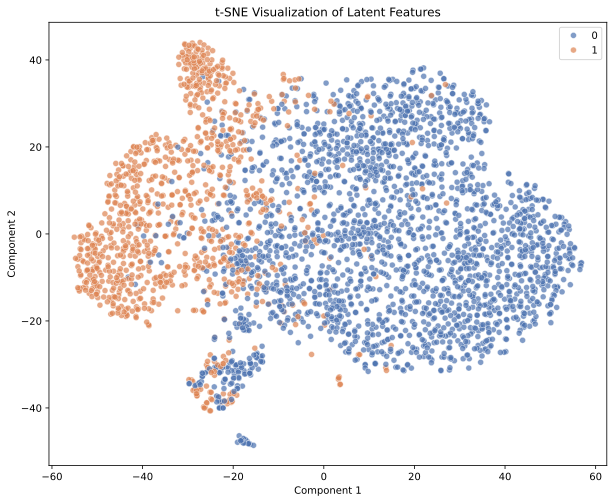

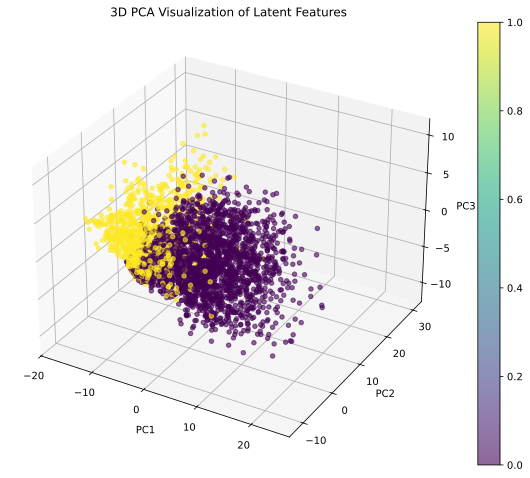

In [17]:
def visualize_latent_features(model, X_test, Y_test, random_state=42):
    """
    Visualizes latent features from the penultimate layer of a CNN using t-SNE and PCA.

    Args:
        model (keras.Model): Trained CNN model.
        X_test (np.ndarray): Test feature data.
        Y_test (np.ndarray): True labels for the test data.
        random_state (int): Seed for reproducibility (default: 42).
    """
    # Extract the penultimate layer activations
    intermediate_model = keras.Model(inputs=model.input, outputs=model.layers[-2].output)
    latent_features = intermediate_model.predict(X_test)

    # 2D Visualization using t-SNE
    tsne = TSNE(n_components=2, random_state=random_state)
    latent_2d = tsne.fit_transform(latent_features)

    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=latent_2d[:, 0], y=latent_2d[:, 1], hue=Y_test, palette='deep', alpha=0.7)
    plt.title('t-SNE Visualization of Latent Features')
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.show()

    # 3D Visualization using PCA
    pca_3d = PCA(n_components=3)
    latent_3d_pca = pca_3d.fit_transform(latent_features)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(
        latent_3d_pca[:, 0],
        latent_3d_pca[:, 1],
        latent_3d_pca[:, 2],
        c=Y_test,
        cmap='viridis',
        alpha=0.6
    )
    ax.set_title('3D PCA Visualization of Latent Features')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    fig.colorbar(scatter)
    plt.show()

visualize_latent_features(model, X_test, Y_test)